# Smoke test — F/T/S partition pipeline

Runs 5 representative partitions for **2 epochs** on the mini dataset.  
Goal: confirm that `build_model`, `train`, and `evaluate` work end-to-end with the new
partition API and that all expected metrics (acc, balanced_acc, f1) appear in results.  
Results at this scale are **not** meaningful — this is a pipeline check only.

| Label | Partition | Notes |
|-------|-----------|-------|
| F5S1 | F F F F F S | linear-probe analog |
| F4T1S1 | F F F F T S | partial fine-tune (stage4 only) |
| F2T2S2 | F F T T S S | balanced mix |
| T5S1 | T T T T T S | full fine-tune |
| S6   | S S S S S S | full scratch |

In [1]:
import sys
from pathlib import Path
import torch
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))

from config   import CONFIG
from models   import build_model, config_label, enumerate_configs
from evaluate import Evaluator
from budget   import EpochBudgetTracker
from train    import train
from utils    import set_seed, estimate_flops

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RESULTS = Path('../results')
RESULTS.mkdir(exist_ok=True)
print(f'Device: {DEVICE}')
print(f'Total valid configs: {len(enumerate_configs())}')

Device: cuda
Total valid configs: 21


In [2]:
EXP_CFG = {
    **CONFIG,
    'dataset_mode':         'mini',
    'backbone':             'resnet50',
    'epochs':               2,
    'batch_size':           32,
    'num_workers':          4,
    'lr':                   1e-4,
    'lr_head':              1e-3,
    'weight_decay':         1e-4,
    'scheduler':            'cosine',
    'use_weighted_sampler': False,
    'seed':                 42,
}

# 5 representative partitions (stem, stage1, stage2, stage3, stage4, head)
SMOKE_CONFIGS = [
    ('F', 'F', 'F', 'F', 'F', 'S'),   # F5S1  — linear-probe analog
    ('F', 'F', 'F', 'F', 'T', 'S'),   # F4T1S1 — partial ft (stage4)
    ('F', 'F', 'T', 'T', 'S', 'S'),   # F2T2S2 — mixed
    ('T', 'T', 'T', 'T', 'T', 'S'),   # T5S1  — full fine-tune
    ('S', 'S', 'S', 'S', 'S', 'S'),   # S6    — full scratch
]

print('Smoke-test partitions:')
for p in SMOKE_CONFIGS:
    print(f'  {config_label(p):10s}  {p}')

Smoke-test partitions:
  F5S1        ('F', 'F', 'F', 'F', 'F', 'S')
  F4T1S1      ('F', 'F', 'F', 'F', 'T', 'S')
  F2T2S2      ('F', 'F', 'T', 'T', 'S', 'S')
  T5S1        ('T', 'T', 'T', 'T', 'T', 'S')
  S6          ('S', 'S', 'S', 'S', 'S', 'S')


In [3]:
all_logs   = {}   # label → eval_log
all_final  = {}   # label → final_results
all_params = {}   # label → (n_trainable, n_total)
all_flops  = {}   # label → flops dict

for partition in SMOKE_CONFIGS:
    label = config_label(partition)
    print(f'\n{"-"*54}')
    print(f'  {label}  {partition}')
    print(f'{"-"*54}')

    set_seed(EXP_CFG['seed'])
    cfg = {**EXP_CFG, 'partition': partition}

    model, n_train, n_total = build_model(partition, cfg)
    all_params[label] = (n_train, n_total)
    print(f'  Trainable: {n_train:,} / {n_total:,}  ({100*n_train/n_total:.1f}%)')

    flops = estimate_flops(model, n_trainable=n_train, n_total=n_total)
    all_flops[label] = flops
    print(f'  Inference FLOPs: {flops["inference_flops"]/1e9:.2f} G  '
          f'Training FLOPs/sample: {flops["training_flops_per_sample"]/1e9:.2f} G')

    evaluator = Evaluator(cfg, DEVICE)
    tracker   = EpochBudgetTracker(eval_every_n=1, max_epochs=cfg['epochs'])

    log, final = train(
        model, cfg, evaluator, tracker,
        eval_splits=['id_val', 'ood_val'],
        final_splits=['id_val', 'ood_val', 'id_test', 'ood_test'],
        checkpoint_dir=None,
    )
    all_logs[label]  = log
    all_final[label] = final

print('\nAll smoke-test runs done.')


------------------------------------------------------
  F5S1  ('F', 'F', 'F', 'F', 'F', 'S')
------------------------------------------------------
  Trainable: 364,722 / 23,872,754  (1.5%)
  Inference FLOPs: 8.20 G  Training FLOPs/sample: 8.45 G
Epoch 1/2  train_loss=1.9449  train_acc=0.477


c:\Users\tomma\Desktop\TRANSFER LEARNING\venv_ood\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\tomma\Desktop\TRANSFER LEARNING\venv_ood\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


step    997  epoch 1.00  elapsed 173s  id_val: acc=0.624 bal=0.347 f1=0.314  ood_val: acc=0.387 bal=0.297 f1=0.236
Epoch 2/2  train_loss=1.5162  train_acc=0.566

Running final evaluation …


c:\Users\tomma\Desktop\TRANSFER LEARNING\venv_ood\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\tomma\Desktop\TRANSFER LEARNING\venv_ood\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\tomma\Desktop\TRANSFER LEARNING\venv_ood\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")



── Final results ──────────────────────────────────────────────
  id_val        acc=0.639  bal_acc=0.349  f1=0.332  loss=1.3239
  ood_val       acc=0.438  bal_acc=0.306  f1=0.253  loss=2.0075
  id_test       acc=0.564  bal_acc=0.379  f1=0.348  loss=1.5700
  ood_test      acc=0.550  bal_acc=0.285  f1=0.270  loss=1.6235

------------------------------------------------------
  F4T1S1  ('F', 'F', 'F', 'F', 'T', 'S')
------------------------------------------------------
  Trainable: 15,329,458 / 23,872,754  (64.2%)
  Inference FLOPs: 8.20 G  Training FLOPs/sample: 18.73 G
Epoch 1/2  train_loss=1.4511  train_acc=0.587


...


── Final results ──────────────────────────────────────────────
  id_val        acc=0.766  bal_acc=0.525  f1=0.481  loss=0.8888
  ood_val       acc=0.524  bal_acc=0.412  f1=0.348  loss=1.6655
  id_test       acc=0.700  bal_acc=0.545  f1=0.495  loss=1.0740
  ood_test      acc=0.650  bal_acc=0.411  f1=0.411  loss=1.3079

------------------------------------------------------
  S6  ('S', 'S', 'S', 'S', 'S', 'S')
------------------------------------------------------
  Trainable: 23,872,754 / 23,872,754  (100.0%)
  Inference FLOPs: 8.20 G  Training FLOPs/sample: 24.60 G
Epoch 1/2  train_loss=2.8430  train_acc=0.302


c:\Users\tomma\Desktop\TRANSFER LEARNING\venv_ood\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


step    997  epoch 1.00  elapsed 173s  id_val: acc=0.443 bal=0.117 f1=0.085  ood_val: acc=0.224 bal=0.072 f1=0.046
Epoch 2/2  train_loss=2.2041  train_acc=0.383

Running final evaluation …


c:\Users\tomma\Desktop\TRANSFER LEARNING\venv_ood\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\tomma\Desktop\TRANSFER LEARNING\venv_ood\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")



── Final results ──────────────────────────────────────────────
  id_val        acc=0.455  bal_acc=0.137  f1=0.120  loss=1.9276
  ood_val       acc=0.263  bal_acc=0.100  f1=0.068  loss=2.5268
  id_test       acc=0.357  bal_acc=0.143  f1=0.104  loss=2.3198
  ood_test      acc=0.411  bal_acc=0.111  f1=0.077  loss=2.1039

All smoke-test runs done.


In [4]:
LABELS = [config_label(p) for p in SMOKE_CONFIGS]

rows = []
for label in LABELS:
    final        = all_final[label]
    n_train, n_t = all_params[label]
    flops        = all_flops[label]
    rows.append({
        'label':                      label,
        'trainable_params':           n_train,
        'trainable_pct':              round(100 * n_train / n_t, 1),
        'training_flops_G':           round(flops['training_flops_per_sample'] / 1e9, 2),
        'id_val_acc':                 final.get('id_val',  {}).get('acc',          float('nan')),
        'id_val_bal_acc':             final.get('id_val',  {}).get('balanced_acc', float('nan')),
        'id_val_f1':                  final.get('id_val',  {}).get('f1',           float('nan')),
        'ood_val_acc':                final.get('ood_val', {}).get('acc',          float('nan')),
        'ood_val_bal_acc':            final.get('ood_val', {}).get('balanced_acc', float('nan')),
        'ood_val_f1':                 final.get('ood_val', {}).get('f1',           float('nan')),
        'elapsed_s':                  all_logs[label][-1]['elapsed_s'] if all_logs[label] else float('nan'),
    })

df = pd.DataFrame(rows).set_index('label')
display_cols = ['trainable_pct', 'training_flops_G',
                'id_val_acc', 'id_val_bal_acc', 'id_val_f1',
                'ood_val_acc', 'ood_val_bal_acc', 'ood_val_f1', 'elapsed_s']
print('\n── Smoke-test results (2 epochs) ──')
print(df[display_cols].to_string())

df.to_csv(RESULTS / 'smoke_test.csv')
print(f'\nSaved → {RESULTS / "smoke_test.csv"}')


── Smoke-test results (2 epochs) ──
        trainable_pct  training_flops_G  id_val_acc  id_val_bal_acc  id_val_f1  ood_val_acc  ood_val_bal_acc  ood_val_f1   elapsed_s
label                                                                                                                               
F5S1              1.5              8.45    0.639192        0.349095   0.332316     0.437593         0.306235    0.253130  173.351294
F4T1S1           64.2             18.73    0.754367        0.486409   0.465487     0.500445         0.400539    0.334504  198.924994
F2T2S2           99.1             24.45    0.720524        0.445937   0.436079     0.476727         0.337569    0.263801  190.071579
T5S1            100.0             24.60    0.765830        0.524892   0.480626     0.524459         0.412335    0.348018  198.687632
S6              100.0             24.60    0.454694        0.136533   0.119874     0.263267         0.099982    0.068368  172.684512

Saved → ..\results\smoke_test.c

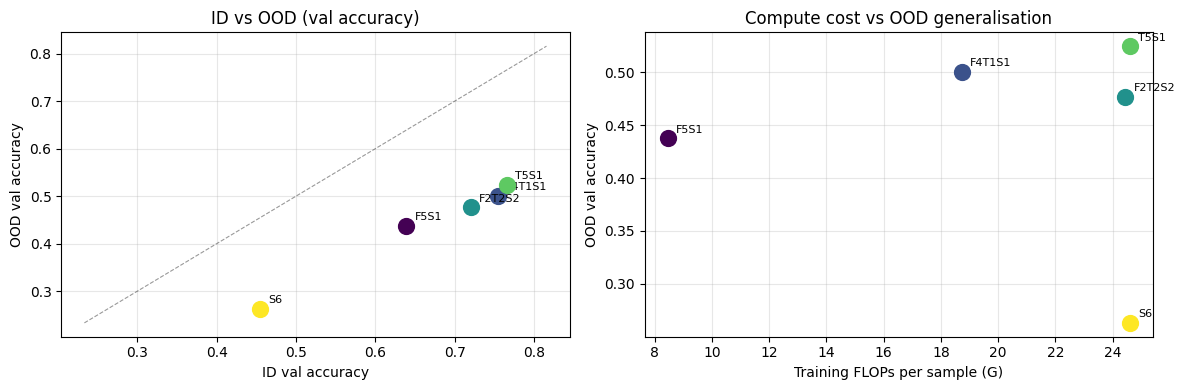

Plots saved.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = plt.cm.viridis([i / (len(LABELS) - 1) for i in range(len(LABELS))])

# ID vs OOD accuracy
for i, label in enumerate(LABELS):
    axes[0].scatter(df.loc[label, 'id_val_acc'], df.loc[label, 'ood_val_acc'],
                    color=colors[i], s=130, zorder=3)
    axes[0].annotate(label, (df.loc[label, 'id_val_acc'], df.loc[label, 'ood_val_acc']),
                     textcoords='offset points', xytext=(6, 4), fontsize=8)
lo = min(df['id_val_acc'].min(), df['ood_val_acc'].min()) - 0.03
hi = max(df['id_val_acc'].max(), df['ood_val_acc'].max()) + 0.05
axes[0].plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.4)
axes[0].set_xlabel('ID val accuracy')
axes[0].set_ylabel('OOD val accuracy')
axes[0].set_title('ID vs OOD (val accuracy)')
axes[0].grid(True, alpha=0.3)

# Training FLOPs vs OOD accuracy
for i, label in enumerate(LABELS):
    axes[1].scatter(df.loc[label, 'training_flops_G'], df.loc[label, 'ood_val_acc'],
                    color=colors[i], s=130, zorder=3)
    axes[1].annotate(label, (df.loc[label, 'training_flops_G'], df.loc[label, 'ood_val_acc']),
                     textcoords='offset points', xytext=(6, 4), fontsize=8)
axes[1].set_xlabel('Training FLOPs per sample (G)')
axes[1].set_ylabel('OOD val accuracy')
axes[1].set_title('Compute cost vs OOD generalisation')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS / 'smoke_test_plots.png', bbox_inches='tight')
plt.show()
print('Plots saved.')